# Setup, Dataset, and Feature Extraction

In [ ]:
# Install dependencies (if needed)
!pip install --upgrade pip
!pip install mediapipe opencv-python
!pip install protobuf==5.26.1

import os
import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from tqdm import tqdm
import zipfile


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 45.7 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
  Using cached protobuf-4.25.7-cp37-abi3-manylinux2014_x86_64.whl.metadata (541 bytes)
Using cached protobuf-4.25.7-cp37-abi3-manylinux2014_x86_64.whl (294 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.26.1
    Uninstalling protobuf-5.26.1:
      Successfully uninstalled protobuf-5.26.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.0 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.7 which is incompatible.
ydf 0.11.0 requires protobuf<6.0.0,>=5.29.1, but you have protobuf 4.25.7 which is incompatible.
  Using cached protobuf-5.26.1-cp37-abi3-manylinux2014_x86_64.whl.metadata (5

In [ ]:
# --- SETUP ---

# UAVGesture zip location on Drive
ZIP_PATH = '/content/drive/MyDrive/UAVGesture2.zip'
# Target extraction directory
DATASET_DIR = '/content/UAVGesture/'

# Extract zip file if not already extracted
if not os.path.exists(DATASET_DIR):
    print(f"Extracting {ZIP_PATH}...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall('/content/')
    print("Extraction completed.")
else:
    print("Dataset already extracted.")

# Sliding window parameters
WINDOW_SIZE = 10  # number of consecutive frames
STRIDE = 5        # move 5 frames at a time

# Output file
OUTPUT_FILE = '/content/pose_sequences.npz'

Dataset already extracted.


In [ ]:
if not os.path.exists('/content/pose_landmarker.task'):
    !wget -O pose_landmarker.task -q https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/1/pose_landmarker_heavy.task

if not os.path.exists('/content/pose_landmarker_full.task'):
    !wget -O pose_landmarker_full.task https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/1/pose_landmarker_full.task

--2025-04-28 19:00:05--  https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/1/pose_landmarker_full.task
Resolving storage.googleapis.com (storage.googleapis.com)... 172.217.194.207, 142.250.4.207, 172.253.118.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|172.217.194.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9398198 (9.0M) [application/octet-stream]
Saving to: ‘pose_landmarker_full.task’

pose_landmarker_ful 100%[===================>]   8.96M  5.50MB/s    in 1.6s    

2025-04-28 19:00:07 (5.50 MB/s) - ‘pose_landmarker_full.task’ saved [9398198/9398198]



In [ ]:
# Initialize MediaPipe PoseLandmarker
base_options = python.BaseOptions(model_asset_path='/content/pose_landmarker_full.task')
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    output_segmentation_masks=False)
detector = vision.PoseLandmarker.create_from_options(options)

# Helper function to normalize landmarks
def normalize_landmarks(landmarks):
    left_hip = landmarks[23]
    right_hip = landmarks[24]
    center = np.array([(left_hip.x + right_hip.x)/2, (left_hip.y + right_hip.y)/2, (left_hip.z + right_hip.z)/2])
    normalized = []
    for lm in landmarks:
        normalized.extend([lm.x - center[0], lm.y - center[1], lm.z - center[2], lm.visibility])
    return normalized

# Map gesture name to integer label
gesture2label = {}
label2gesture = {}


In [18]:
sequences = []
labels = []

# # Sanity Check
# from PIL import Image
# pil_img = Image.new('RGB', (60, 30), color = 'red')
# image = mp.Image(
#     image_format=mp.ImageFormat.SRGB, data=np.asarray(pil_img))

gesture_folders = sorted(os.listdir(DATASET_DIR))
for idx, gesture in enumerate(gesture_folders):
    gesture2label[gesture] = idx
    label2gesture[idx] = gesture
    gesture_folder_path = os.path.join(DATASET_DIR, gesture)

    video_files = [f for f in os.listdir(gesture_folder_path) if f.endswith('.mp4')]
    for video_file in tqdm(video_files, desc=f'Processing {gesture}'):
        video_path = os.path.join(gesture_folder_path, video_file)

        cap = cv2.VideoCapture(video_path)
        frame_buffer = []

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            image_rgb = np.ascontiguousarray(image_rgb)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
            detection_result = detector.detect(mp_image)

            if detection_result.pose_landmarks and detection_result.pose_landmarks[0]:
                landmarks = detection_result.pose_landmarks[0]
                features = normalize_landmarks(landmarks)
                frame_buffer.append(features)
            else:
                frame_buffer.append([0]*132)

        cap.release()

        # Apply sliding window over collected frames
        for start_idx in range(0, len(frame_buffer) - WINDOW_SIZE + 1, STRIDE):
            window = frame_buffer[start_idx:start_idx + WINDOW_SIZE]
            if len(window) == WINDOW_SIZE:
                sequences.append(window)
                labels.append(idx)

# Convert to arrays
sequences = np.array(sequences)
labels = np.array(labels)

print('Sequences shape:', sequences.shape)
print('Labels shape:', labels.shape)

# Save dataset
np.savez(OUTPUT_FILE, sequences=sequences, labels=labels, gesture2label=gesture2label, label2gesture=label2gesture)

print(f'Dataset saved to {OUTPUT_FILE}')

Processing Wave Off: 100%|██████████| 7/7 [02:27<00:00, 21.09s/it]


Sequences shape: (7261, 10, 132)
Labels shape: (7261,)
Dataset saved to /content/pose_sequences.npz


# Model Training

In [ ]:
# Install dependencies (if needed)
!pip install scikit-learn tensorflow

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


In [19]:
# --- Load Dataset ---

DATA_PATH = '/content/pose_sequences.npz'

print(f"Loading dataset from {DATA_PATH}")

loaded = np.load(DATA_PATH, allow_pickle=True)
sequences = loaded['sequences']
labels = loaded['labels']
gesture2label = loaded['gesture2label'].item()
label2gesture = loaded['label2gesture'].item()

print('Sequences shape:', sequences.shape)
print('Labels shape:', labels.shape)

# --- Prepare Data ---

X = sequences  # (num_samples, 10, 132)
y = to_categorical(labels)  # One-hot encoding

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=labels)

print('Train set:', X_train.shape, y_train.shape)
print('Test set:', X_test.shape, y_test.shape)


Loading dataset from /content/pose_sequences.npz
Sequences shape: (7261, 10, 132)
Labels shape: (7261,)
Train set: (5808, 10, 132) (5808, 13)
Test set: (1453, 10, 132) (1453, 13)


In [20]:
# --- Build LSTM Model ---

num_classes = y.shape[1]

model = Sequential([
    LSTM(128, input_shape=(X.shape[1], X.shape[2]), return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 128)            │       133,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 13)             │           845 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,733 (557.55 KB)

 Trainable params: 142,733 (557.55 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
182/182 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.1875 - loss: 2.3291 - val_accuracy: 0.5354 - val_loss: 1.1385
Epoch 2/30
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4976 - loss: 1.3175 - val_accuracy: 0.5747 - val_loss: 1.0031
Epoch 3/30
182/182 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5361 - loss: 1.1190 - val_accuracy: 0.5953 - val_loss: 0.9221
Epoch 4/30
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5733 - loss: 1.0410 - val_accuracy: 0.6297 - val_loss: 0.8608
Epoch 5/30
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5792 - loss: 0.9752 - val_accuracy: 0.6125 - val_loss: 0.8820
Epoch 6/30
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5873 - loss: 0.9557 - val_accuracy: 0.6380 - val_loss: 0.7982
Epoch 7/30
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6218 - loss: 0.8739 - val_accuracy: 0.6442 - val_loss: 0.7637
Epoch 8/30
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6272 - loss: 0.8390 - val_accuracy: 0.

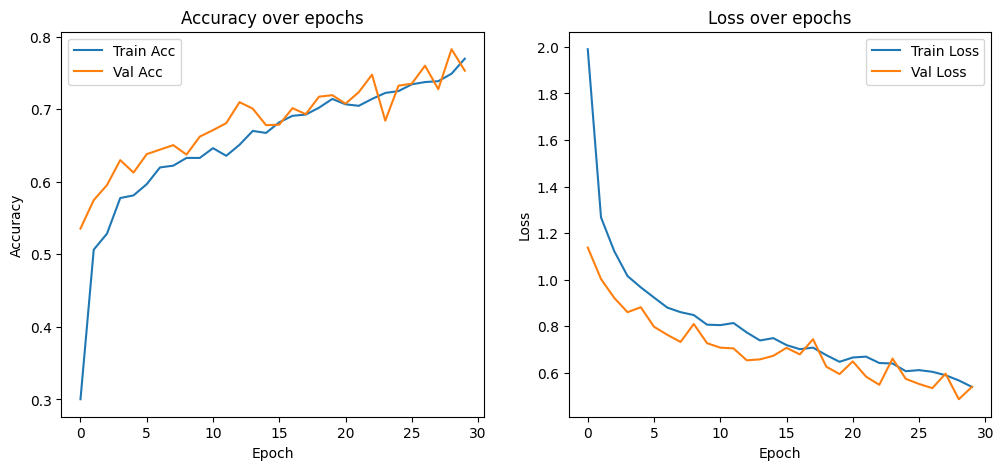

In [21]:
# --- Train Model ---

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32
)

# --- Plot Training Curves ---

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


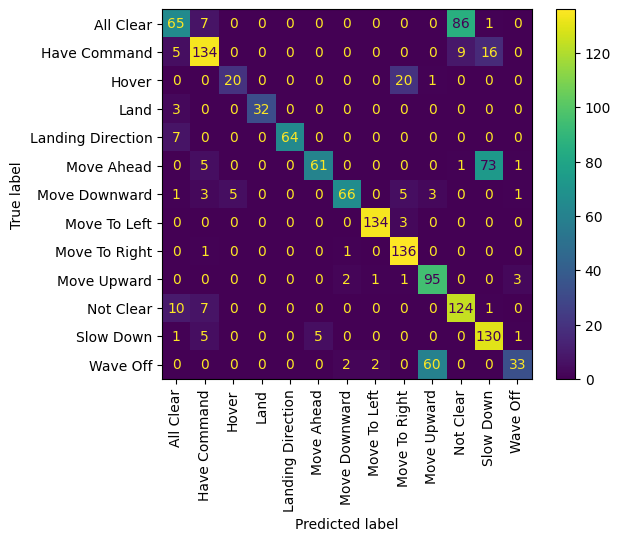

                   precision    recall  f1-score   support

        All Clear       0.71      0.41      0.52       159
     Have Command       0.83      0.82      0.82       164
            Hover       0.80      0.49      0.61        41
             Land       1.00      0.91      0.96        35
Landing Direction       1.00      0.90      0.95        71
       Move Ahead       0.92      0.43      0.59       141
    Move Downward       0.93      0.79      0.85        84
     Move To Left       0.98      0.98      0.98       137
    Move To Right       0.82      0.99      0.90       138
      Move Upward       0.60      0.93      0.73       102
        Not Clear       0.56      0.87      0.69       142
        Slow Down       0.59      0.92      0.72       142
         Wave Off       0.85      0.34      0.49        97

         accuracy                           0.75      1453
        macro avg       0.81      0.75      0.75      1453
     weighted avg       0.79      0.75      0.74      

In [22]:
# --- Evaluate Model ---

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels=[label2gesture[i] for i in range(num_classes)])
cmd.plot(xticks_rotation=90)
plt.show()

print(classification_report(y_true, y_pred, target_names=[label2gesture[i] for i in range(num_classes)]))

# --- Save Model ---

MODEL_SAVE_PATH = '/content/gesture_classifier.h5'
model.save(MODEL_SAVE_PATH)
print(f"Model saved to {MODEL_SAVE_PATH}")